In [1]:
input_ff = 'openff_unconstrained-2.3.0-rc2.offxml'

## Get data

In [2]:
from qcportal import PortalClient
from openff.qcsubmit.results import (
    BasicResultCollection,
    OptimizationResultCollection,
    TorsionDriveResultCollection,
)
from openff.units import unit
from tqdm import tqdm
import openmm
import numpy as np
from qcportal.optimization.record_models import OptimizationRecord
from qcportal.torsiondrive.record_models import TorsiondriveRecord

import descent.targets.energy
import json 
from loguru import logger

from openff.toolkit import ForceField, Molecule
import descent.train
import yaml
from pydantic import BaseModel, Field, validator

import datasets

LICENSE: Could not open license file specified by OE_LICENSE environment variable "/Users/jeffreywagner/oe_license.txt"
LICENSE: Could not open license file "oe_license.txt" in local directory
LICENSE: N.B. OE_DIR environment variable is not set
LICENSE: No product keys!
LICENSE: No product keys!
LICENSE: No product keys!
The OpenEye Toolkits are found to be installed but not licensed and therefore will not be used.
The OpenEye Toolkits require a (free for academics) license, see https://docs.eyesopen.com/toolkits/python/quickstart-python/license.html
LICENSE: No product keys!
The OpenEye Toolkits are found to be installed but not licensed and therefore will not be used.
The OpenEye Toolkits require a (free for academics) license, see https://docs.eyesopen.com/toolkits/python/quickstart-python/license.html
/Users/jeffreywagner/micromamba/envs/descent-workflow/lib/python3.12/site-packages/openff/amber_ff_ports/amber_ff_ports.py:8: UserWarning: pkg_resources is deprecated as an API. See 

In [3]:
qc_client = PortalClient("https://api.qcarchive.molssi.org:443", cache_dir=".")

In [4]:
optimization_result_collection = OptimizationResultCollection.from_server(
    client=qc_client,
    datasets=[
        #"OpenFF Gen 2 Opt Set 3 Pfizer Discrepancy",
        #"OpenFF Gen 2 Opt Set 4 eMolecules Discrepancy",
        "OpenFF Torsion Multiplicity Optimization Training Coverage Supplement v1.0"
        #"OpenFF Alkane Torsion Drives v1.0"
    ],
    spec_name="default",
)
records = optimization_result_collection.to_records()

In [5]:
torsiondrive_result_collection = TorsionDriveResultCollection.from_server(
    client=qc_client,
    datasets=[
        "OpenFF Alkane Torsion Drives v1.0"
    ],
    spec_name="default",
)
records = torsiondrive_result_collection.to_records()

* Get training data
  * ✓ Handle either opt or TD
  * (TO DO) Filter high forces 
* Format it
  * ✓ Convert QC data to descent input format https://github.com/fjclark/descent-workflow/blob/main/workflow/get_data.py#L179
  * Will get MSM starting point FF later
  * ✓ (create interchanges)
  * ✓ (convert interchanges) https://github.com/fjclark/descent-workflow/blob/1e8d35c69da66fe5aa0baa27d2f50c3b6921f9be/workflow/parameterise.py#L140
  * ✓ (convert ff to "cuda" or CPU equivalent) https://github.com/fjclark/descent-workflow/blob/main/workflow/train.py#L318-L321
  * ✓ (output to pyarrow file)
* Run descent
  * ✓ (figure out settings)
    * (numerical settings in configs) https://github.com/fjclark/descent-workflow/blob/main/workflow/configs/spice2_linearised_harmonics_minibatch.yaml
    * (those get passed to descent) https://github.com/fjclark/descent-workflow/blob/main/workflow/train.py#L102
    * `Trainable` class https://github.com/SimonBoothroyd/descent/blob/main/descent/train.py#L176
  * ✓ (figure out how to run locally/without GPU)
  * (TO DO) write output FF
* Show plots
  * (TO DO) Train and test loss
  * (TO DO) Parameter change

## Convert QC data to descent format

In [6]:
#[record[1].n_conformers for record in records]
len(records), len(set([record[1].to_smiles(mapped=True) for record in records]))

(192, 50)

In [7]:
records[0][0].minimum_optimizations[(15,)].trajectory[-1].properties["dft total gradient"]#  * HARTREE_TO_KCAL

[-1.067201175755845e-06,
 4.813671509450743e-06,
 -9.495802876291116e-06,
 1.419377314822325e-06,
 2.3384912669087757e-06,
 5.058209541338116e-07,
 5.706808811660707e-06,
 1.7903841696280702e-06,
 7.919290955700074e-06,
 3.1830015490235232e-06,
 2.200465963111899e-06,
 3.394363240644745e-06,
 -1.9347628292311417e-05,
 -1.888898537776517e-05,
 6.519584604595605e-06,
 -0.00200182514435771,
 -0.0022020703287048905,
 0.0002750951379738684,
 0.002261031509723031,
 0.001804340232383852,
 -0.0003549166480558104,
 -2.4234922863166784e-06,
 1.7855701463080653e-06,
 4.374633330496915e-06,
 -1.737037429652233e-06,
 2.587759712237788e-06,
 -2.898723154868966e-07,
 -1.0322596545777186e-06,
 -1.9716166062034592e-06,
 1.2743955517477434e-06,
 -7.810564361116618e-07,
 1.764327518062386e-08,
 -8.817059353632869e-07,
 3.804293702303288e-07,
 1.304984740097448e-06,
 2.9772364333005726e-06,
 -3.983514850786745e-06,
 6.143603942601887e-07,
 2.4089038111315623e-06,
 -2.617392210754765e-06,
 6.20337281722256

In [8]:

HARTREE_TO_KCAL = (
    1.0 * openmm.unit.hartree * openmm.unit.AVOGADRO_CONSTANT_NA
).value_in_unit(openmm.unit.kilocalorie_per_mole)

BOHR_TO_ANGSTROM = (1.0 * openmm.unit.bohr).value_in_unit(openmm.unit.angstrom)

collapsed_conformers = {}
for record in records:
    smiles = record[1].to_smiles(mapped=True)
    collapsed_conformers[smiles] = collapsed_conformers.get(smiles, list()) + [record]
all_data = []
all_smiles = set()

for smiles, these_records in tqdm(collapsed_conformers.items(), 
                                     desc="Extracting dataset", ncols=40):
    # extract the data
    all_smiles.add(smiles)
    energies = []
    coords = []
    forces = []
    
    for record in these_records:
        if isinstance(record[0], OptimizationRecord):
            #n_conformers = record["conformations"].shape[0]
            n_conformers = len(records)
            #assert len(record["dft_total_energy"]) == n_conformers
            #energies = [
            #    record["dft_total_energy"][i] * HARTEE_TO_KCAL
            #    for i in range(n_conformers)
            #]
            energies.append(record[0].trajectory[-1].properties["dft total energy"]  * HARTREE_TO_KCAL )
                        #for record in these_records]
            
            #coords = [
            #    record["conformations"][i] * BOHR_TO_ANGSTROM
            #    for i in range(n_conformers)
            #]
            coords.append(record[1].conformers[0].m_as(unit.angstrom) )
                      #for record in these_records]
            #forces = [
            #    record["dft_total_gradient"][i]
            #    * -1
            #    * (HARTEE_TO_KCAL / BOHR_TO_ANGSTROM)
            #    for i in range(n_conformers)
            #]
            forces.append(np.array(record[0].trajectory[-1].properties["dft total gradient"])
                        * -1
                        * (HARTREE_TO_KCAL / BOHR_TO_ANGSTROM)
                         )
                        #for record in these_records]
    
        elif isinstance(record[0], TorsiondriveRecord):
            # the keys in minimum_optimizations arethe driven torsion 
            # angles, but we don't really care about those
            for min_opt in record[0].minimum_optimizations.values():
                
                #n_conformers = record["conformations"].shape[0]
                #n_conformers = len(record)
                #assert len(record["dft_total_energy"]) == n_conformers
                #energies = [
                #    record["dft_total_energy"][i] * HARTEE_TO_KCAL
                #    for i in range(n_conformers)
                #]
                energies.append(min_opt.trajectory[-1].properties["dft total energy"] * HARTREE_TO_KCAL) 
                #= [record[0].trajectory[-1].properties["dft total energy"] 
                            #for record in these_records]
                
                #coords = [
                #    record["conformations"][i] * BOHR_TO_ANGSTROM
                #    for i in range(n_conformers)
                #]
                coords.append(min_opt.final_molecule.geometry * BOHR_TO_ANGSTROM)
                              # = [record[1].conformers[0].m_as(unit.angstrom) 
                      #    for record in these_records]
                #forces = [
                #    record["dft_total_gradient"][i]
                #    * -1
                #    * (HARTEE_TO_KCAL / BOHR_TO_ANGSTROM)
                #    for i in range(n_conformers)
                #]
                forces.append(np.array(min_opt.trajectory[-1].properties["dft total gradient"])
                              * -1
                            * (HARTREE_TO_KCAL / BOHR_TO_ANGSTROM))
                #= [np.array(record[0].trajectory[-1].properties["dft total gradient"])
                #            * -1
                #            * (HARTEE_TO_KCAL / BOHR_TO_ANGSTROM)
                #            for record in these_records]
        
        else:
            1/0
    all_data.append(
        {
            "smiles": smiles,
            "coords": coords,
            "energy": energies,
            "forces": forces,
        }
    )

Extracting dataset:   6%| | 3/50 [06:57<
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x107fd3140>>
Traceback (most recent call last):
  File "/Users/jeffreywagner/micromamba/envs/descent-workflow/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
KeyboardInterrupt: 


KeyboardInterrupt: 

In [32]:

output_dir = "output"

dataset = descent.targets.energy.create_dataset(all_data)
dataset.save_to_disk(output_dir)
unique_smiles = dataset.unique("smiles")
logger.info(
    f"Found {len(dataset)} ({len(unique_smiles)} unique) SMILES in dataset"
)
with open(f"{output_dir}/smiles.json", "w") as file:
    json.dump(list(unique_smiles), file)

/Users/jeffreywagner/micromamba/envs/descent-workflow/lib/python3.12/site-packages/descent/targets/energy.py:51: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1719361022906/work/torch/csrc/utils/tensor_new.cpp:277.)
  "coords": torch.tensor(entry["coords"]).flatten().tolist(),


Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

2025-10-09 19:43:45.176 | INFO     | __main__:<module>:9 - Found 50 (50 unique) SMILES in SPICE2


In [4]:

dataset = datasets.Dataset.load_from_disk(f"output")
all_data = dataset
n_entries = len(dataset)

unique_smiles = dataset.unique("smiles")
#topologies = {k: v for k, v in topologies.items() if k in unique_smiles}


# Create interchanges

In [5]:
ff = ForceField(input_ff)

In [6]:
smiles2top = {}
interchanges = []
for mol in tqdm(all_data, desc="Creating interchanges", ncols=40):
    offmol = Molecule.from_mapped_smiles(mol['smiles'], allow_undefined_stereo=True)
    interchanges.append(ff.create_interchange(offmol.to_topology()))
 


Creating interchanges:   0%| | 0/50 [00:WARNING:openff.toolkit.utils.toolkit_registry:The OpenEye Toolkits are found to be installed but not licensed and therefore will not be used.
The OpenEye Toolkits require a (free for academics) license, see https://docs.eyesopen.com/toolkits/python/quickstart-python/license.html
Creating interchanges: 100%|█| 50/50 [00


In [33]:
import smee.converters

force_field, topologies = smee.converters.convert_interchange(interchanges)
smiles2top = {smiles: topology for smiles, topology in zip(unique_smiles, topologies)}


In [34]:
force_field = force_field.to("cpu")
topologies = {
    smiles: topology.to("cpu") for smiles, topology in smiles2top.items()
}



In [35]:

class WorkflowConfig(BaseModel):
    """
    Configuration for the workflow.
    """

    #experiment_name: str = Field(default="", description="Name of the experiment.")
    #experiment_description: str = Field(
    #    default="", description="Description of the experiment."
    #)
    #data_dir: Path = Field(
    #    default="data/espaloma", description="Directory where the data is stored."
    #)
    #get_data_fn: str = Field(
    #    default="get_data.get_data_espaloma", description="Function to get the data."
    #)
    #get_data_output_smiles: Path = Field(
    #    default="data/espaloma/data-raw/smiles.json",
    #    description="Output that snakemake will look for.",
    #)

    #starting_force_field_path: Path = Field(
    #    default="input_ff/lj-sage-2-2-msm-0-expanded-torsions.offxml",
    #    description="Path to the starting force field.",
    #)

    #filter_and_cluster_fn: str = Field(
    #    default="filter.filter_and_cluster_espaloma",
    #    description="Function to filter and cluster the data.",
    #)

    batch_size: int = Field(default=500, description="Batch size for training.")

    #minibatch_size: int = Field(default=256, description="Minibatch size for training.")

    n_epochs: int = Field(default=1000, description="Number of epochs for training.")

    learning_rate: float = Field(
        default=1./300, description="Learning rate for training."
    )

    energy_weight: float = Field(default=1.0, description="Weight for the energy loss.")

    force_weight: float = Field(default=1.0, description="Weight for the force loss.")

    torsion_weight: float = Field(
        default=0.0, description="Weight for the torsion regularization."
    )

    torsion_reg: str = Field(
        default="l1", description="Regularization for the torsion loss."
    )

    attributes: dict = Field(
        default_factory=dict, description="Trainable attributes for the force field."
    )

    parameters: dict = Field(
        default_factory=dict #lambda: {
            #"LinearBonds": {
            #    "cols": ["k1", "k2"],
            #    "scales": {"k1": 0.0028, "k2": 0.028},
            #    "limits": {"k1": [None, None], "k2": [None, None]},
            #},
            #"LinearAngles": {
            #    "cols": ["k1", "k2"],
            #    "scales": {"k1": 0.0115, "k2": 0.0115},
            #    "limits": {"k1": [None, None], "k2": [None, None]},
            #},
            #"ProperTorsions": {"cols": ["k"], "scales": {"k": 8.72}},
            #"ImproperTorsions": {"cols": ["k"], "scales": {"k": 2.03}},
        #}
        ,
        description="Trainable parameters for the force field.",
    )

    #model_config = {
    #    "populate_by_name": True,  # So we automatically get Paths from strings
    #}

#dir(yaml)
#config = yaml.safe_load(open("micro_fit.yaml"))
#parameters = config['parameters']
#attributes = config['attributes']
with open('micro_fit.yaml', "r") as f:
    data = yaml.safe_load(f)
    config = WorkflowConfig(**data)

In [36]:
parameters = {}
for k, v in config.parameters.items():
    if "include" in v:
        v["include"] = [PotentialKey(id=key_id) for key_id in v["include"]]
    if "exclude" in v:
        v["exclude"] = [PotentialKey(id=key_id) for key_id in v["exclude"]]

    parameters[k] = descent.train.ParameterConfig(**v)

attributes = {
    k: descent.train.AttributeConfig(**v) for k, v in config.attributes.items()
}

In [37]:
print(parameters)

{'Bonds': ParameterConfig(cols=['k', 'length'], scales={'k': 0.0014, 'length': 0.01}, limits={'k': (None, None), 'length': (None, None)}, include=None, exclude=None), 'Angles': ParameterConfig(cols=['k', 'angle'], scales={'k': 0.016, 'angle': 0.01}, limits={'k': (None, None), 'angle': (None, None)}, include=None, exclude=None), 'ProperTorsions': ParameterConfig(cols=['k'], scales={'k': 1.3}, limits={}, include=None, exclude=None), 'ImproperTorsions': ParameterConfig(cols=['k'], scales={'k': 0.23}, limits={}, include=None, exclude=None)}


In [38]:
trainable = descent.train.Trainable(
    force_field=force_field,
    parameters=parameters,
    attributes=attributes
)

## Simon's version

#trainable = TrainableParameters(
#    force_field,
#    {
#        "Bonds": ParameterConfig(
#            cols=["k", "length"],
#            scales={"k": 1.0 / 100.0, "length": 1.0},
#            constraints={"k": (0.0, None), "length": (0.0, None)},
#        ),
#        "Angles": ParameterConfig(
#            cols=["k", "angle"],
#            scales={"k": 1.0 / 100.0, "angle": 1.0},
#            constraints={"k": (0.0, None), "angle": (0.0, math.pi)},
#        ),
#        "ProperTorsions": ParameterConfig(cols=["k"], scales={"k": 1.0}),
#    },
#)


In [45]:
import torch
x = trainable.to_values().to("cpu")
optimizer = torch.optim.Adam([x], lr=config.learning_rate/50, amsgrad=True)

# Get initial torsion values for regularization.
#k_col_torsion = force_field.potentials_by_type["ProperTorsions"].parameter_cols.index("k")
#initial_torsions = force_field.potentials_by_type["ProperTorsions"].parameters[:, k_col_torsion].detach()
test_losses = []
train_losses = []

## Finlay/descent-workflow inspired fitting

In [47]:
for i in range(config.n_epochs):
    #losses: dict[str, list[torch.Tensor]] = {"train": [], "test": []}

    #for dataset_name, dataset in {
    #    "train": minibatch,
    #    "test": dataset_test,
    #}.items():
    #    losses[dataset_name].extend(
    #        get_losses(
    #            config,
    #            trainable,
    #            x,
    #            dataset,
    #            topologies,
    #            initial_torsions,
    #        )
    #    )
    #    if dataset_name == "train":

    ff = trainable.to_force_field(x)

    total_loss, energy_loss, force_loss, grad = (
        torch.zeros(size=(1,), device=x.device.type),
        torch.zeros(size=(1,), device=x.device.type),
        torch.zeros(size=(1,), device=x.device.type),
        None,
    )

    #for batch in dataset_batch_iterator(dataset, config.batch_size):
    true_batch_size = len(dataset)

    #    cuda_batch = prepare_cuda_batch(batch)

    cpu_batch = []
    for entry in dataset:
        for key, value in entry.items():
            if key in ["coords", "energy", "forces"]:
                entry[key] = value.to("cpu")
            else:
                entry[key] = value
        cpu_batch.append(entry)
        
    e_ref, e_pred, f_ref, f_pred = descent.targets.energy.predict(
            cpu_batch, ff, topologies, "mean"
        )

    batch_loss_energy = ((e_pred - e_ref) ** 2).sum() / true_batch_size
    batch_loss_force = ((f_pred - f_ref) ** 2).sum() / true_batch_size

    batch_loss = (
        config.energy_weight * batch_loss_energy
        + config.force_weight * batch_loss_force
    )

    (batch_grad,) = torch.autograd.grad(batch_loss, x, create_graph=True)
    batch_grad = batch_grad.detach()
    grad = batch_grad# if grad is None else grad + batch_grad

    total_loss += batch_loss.detach()
    energy_loss += batch_loss_energy.detach()
    force_loss += batch_loss_force.detach()

    #torsion_prior = compute_torsion_prior(config, ff, initial_torsions, x, grad)
    #if config.torsion_weight > 0.0:
    #    total_loss += torsion_prior.detach()

    x.grad = grad

    #return total_loss, energy_loss, force_loss, torsion_prior
    
    optimizer_loss = optimizer.step()
    print(f"epoch {i=}")  
    print(f'{optimizer_loss=}')
    print(f'{total_loss=}')
    print(f'{energy_loss=}')
    print(f'{force_loss=}')
    optimizer.zero_grad()

epoch i=0
optimizer_loss=None
total_loss=tensor([5.6311])
energy_loss=tensor([0.4361])
force_loss=tensor([5.1950])
epoch i=1
optimizer_loss=None
total_loss=tensor([367773.2812])
energy_loss=tensor([158.1414])
force_loss=tensor([367615.1250])
epoch i=2
optimizer_loss=None
total_loss=tensor([16420.9531])
energy_loss=tensor([15.4026])
force_loss=tensor([16405.5508])
epoch i=3
optimizer_loss=None
total_loss=tensor([146037.2812])
energy_loss=tensor([38.3777])
force_loss=tensor([145998.9062])
epoch i=4
optimizer_loss=None
total_loss=tensor([211737.9844])
energy_loss=tensor([62.6272])
force_loss=tensor([211675.3594])
epoch i=5
optimizer_loss=None
total_loss=tensor([108237.4766])
energy_loss=tensor([32.2272])
force_loss=tensor([108205.2500])
epoch i=6
optimizer_loss=None
total_loss=tensor([14924.9688])
energy_loss=tensor([4.1367])
force_loss=tensor([14920.8320])
epoch i=7
optimizer_loss=None
total_loss=tensor([17156.3594])
energy_loss=tensor([10.6254])
force_loss=tensor([17145.7344])
epoch i=8

## Finlay's approach but refactored to do train/test split

In [46]:
#import random
#train_idxs = [*range(0, len(dataset), 2)]
#test_idxs = [*range(1, len(dataset), 2)]
train_idxs = [*range(40)]
test_idxs = [*range(40, len(dataset))]
#test_idxs = [*range(10)]
#train_idxs = [*range(10, len(dataset))]

In [47]:
dir(dataset)
dataset.select(train_idxs)

Dataset({
    features: ['smiles', 'coords', 'energy', 'forces'],
    num_rows: 40
})

In [48]:
    

for i in range(config.n_epochs):
    #losses: dict[str, list[torch.Tensor]] = {"train": [], "test": []}

    #for dataset_name, dataset in {
    #    "train": minibatch,
    #    "test": dataset_test,
    #}.items():
    #    losses[dataset_name].extend(
    #        get_losses(
    #            config,
    #            trainable,
    #            x,
    #            dataset,
    #            topologies,
    #            initial_torsions,
    #        )
    #    )
    #    if dataset_name == "train":

    ff = trainable.to_force_field(x)

    total_loss, energy_loss, force_loss, grad = (
        torch.zeros(size=(1,), device=x.device.type),
        torch.zeros(size=(1,), device=x.device.type),
        torch.zeros(size=(1,), device=x.device.type),
        None,
    )

    #for batch in dataset_batch_iterator(dataset, config.batch_size):
    true_batch_size = len(dataset)

    #    cuda_batch = prepare_cuda_batch(batch)
    for name, subset in [('test', test_idxs), ('train', train_idxs)]:
        cpu_batch = []
        for entry in dataset.select(subset):
            for key, value in entry.items():
                if key in ["coords", "energy", "forces"]:
                    entry[key] = value.to("cpu")
                else:
                    entry[key] = value
            cpu_batch.append(entry)
            
        e_ref, e_pred, f_ref, f_pred = descent.targets.energy.predict(
                cpu_batch, ff, topologies, "mean"
            )
    
        batch_loss_energy = ((e_pred - e_ref) ** 2).sum() / true_batch_size
        batch_loss_force = ((f_pred - f_ref) ** 2).sum() / true_batch_size
    
        batch_loss = (
            config.energy_weight * batch_loss_energy
            + config.force_weight * batch_loss_force
        )
        if name == 'test':
            print(f"test loss {batch_loss}")
            test_losses.append(batch_loss.detach())
    (batch_grad,) = torch.autograd.grad(batch_loss, x, create_graph=True)
    batch_grad = batch_grad.detach()
    grad = batch_grad# if grad is None else grad + batch_grad

    total_loss += batch_loss.detach()
    train_losses.append(batch_loss.detach())
    energy_loss += batch_loss_energy.detach()
    force_loss += batch_loss_force.detach()

    #torsion_prior = compute_torsion_prior(config, ff, initial_torsions, x, grad)
    #if config.torsion_weight > 0.0:
    #    total_loss += torsion_prior.detach()

    x.grad = grad

    #return total_loss, energy_loss, force_loss, torsion_prior
    
    optimizer_loss = optimizer.step()
    print(f"epoch {i=}")  
    print(f'{optimizer_loss=}')
    print(f'{total_loss=}')
    print(f'{energy_loss=}')
    print(f'{force_loss=}')
    print()
    optimizer.zero_grad()

test loss 6.7990803718566895
epoch i=0
optimizer_loss=None
total_loss=tensor([28.6744])
energy_loss=tensor([0.8953])
force_loss=tensor([27.7791])

test loss 71.11884307861328
epoch i=1
optimizer_loss=None
total_loss=tensor([313.5205])
energy_loss=tensor([1.1952])
force_loss=tensor([312.3253])

test loss 7.397585868835449
epoch i=2
optimizer_loss=None
total_loss=tensor([38.0534])
energy_loss=tensor([0.9914])
force_loss=tensor([37.0621])

test loss 16.330921173095703
epoch i=3
optimizer_loss=None
total_loss=tensor([66.2436])
energy_loss=tensor([0.8132])
force_loss=tensor([65.4303])

test loss 39.77081298828125
epoch i=4
optimizer_loss=None
total_loss=tensor([167.5618])
energy_loss=tensor([0.7135])
force_loss=tensor([166.8483])

test loss 27.312253952026367
epoch i=5
optimizer_loss=None
total_loss=tensor([116.4114])
energy_loss=tensor([0.6690])
force_loss=tensor([115.7424])

test loss 6.604089260101318
epoch i=6
optimizer_loss=None
total_loss=tensor([28.1258])
energy_loss=tensor([0.6543])

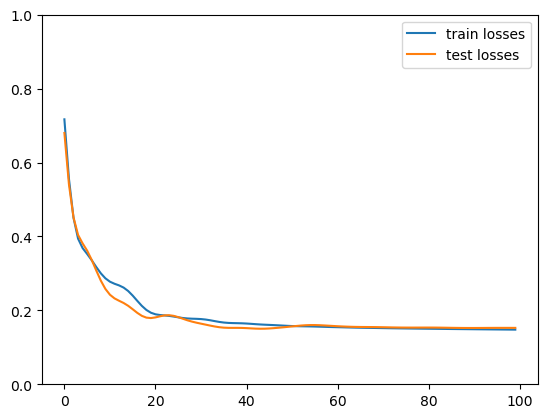

In [42]:
# LR=1/1000

from matplotlib import pyplot
pyplot.plot([i/len(train_idxs) for i in train_losses], label='train losses')
pyplot.plot([i/len(test_idxs) for i in test_losses], label='test losses')
pyplot.legend()
pyplot.ylim(0, 1)
pyplot.show()

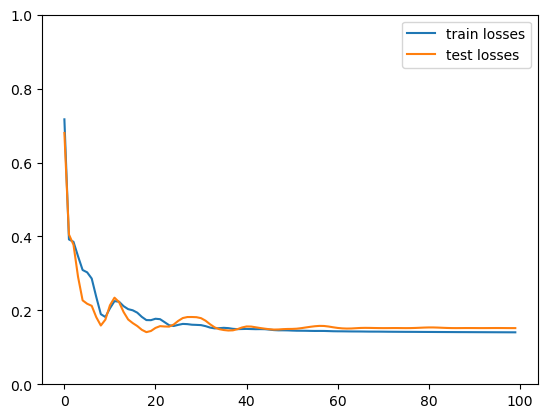

In [31]:
# LR=1/300

from matplotlib import pyplot
pyplot.plot([i/len(train_idxs) for i in train_losses], label='train losses')
pyplot.plot([i/len(test_idxs) for i in test_losses], label='test losses')
pyplot.legend()
pyplot.ylim(0, 1)
pyplot.show()

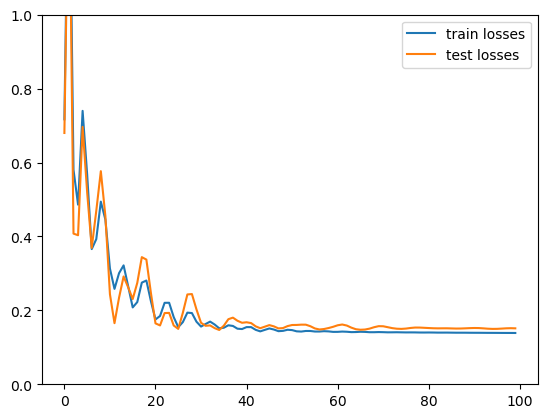

In [44]:
# LR=1/100

from matplotlib import pyplot
pyplot.plot([i/len(train_idxs) for i in train_losses], label='train losses')
pyplot.plot([i/len(test_idxs) for i in test_losses], label='test losses')
pyplot.legend()
pyplot.ylim(0, 1)
pyplot.show()

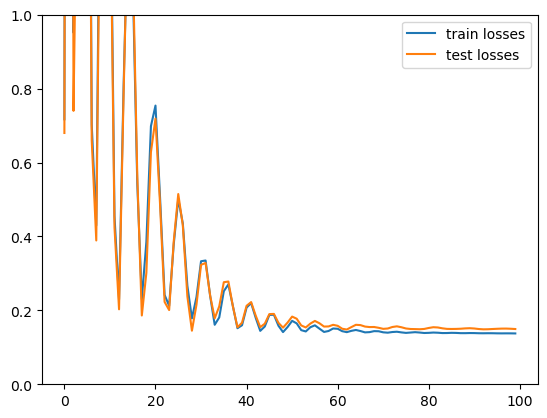

In [49]:
# LR=1/50
from matplotlib import pyplot
pyplot.plot([i/len(train_idxs) for i in train_losses], label='train losses')
pyplot.plot([i/len(test_idxs) for i in test_losses], label='test losses')
pyplot.legend()
pyplot.ylim(0, 1)
pyplot.show()

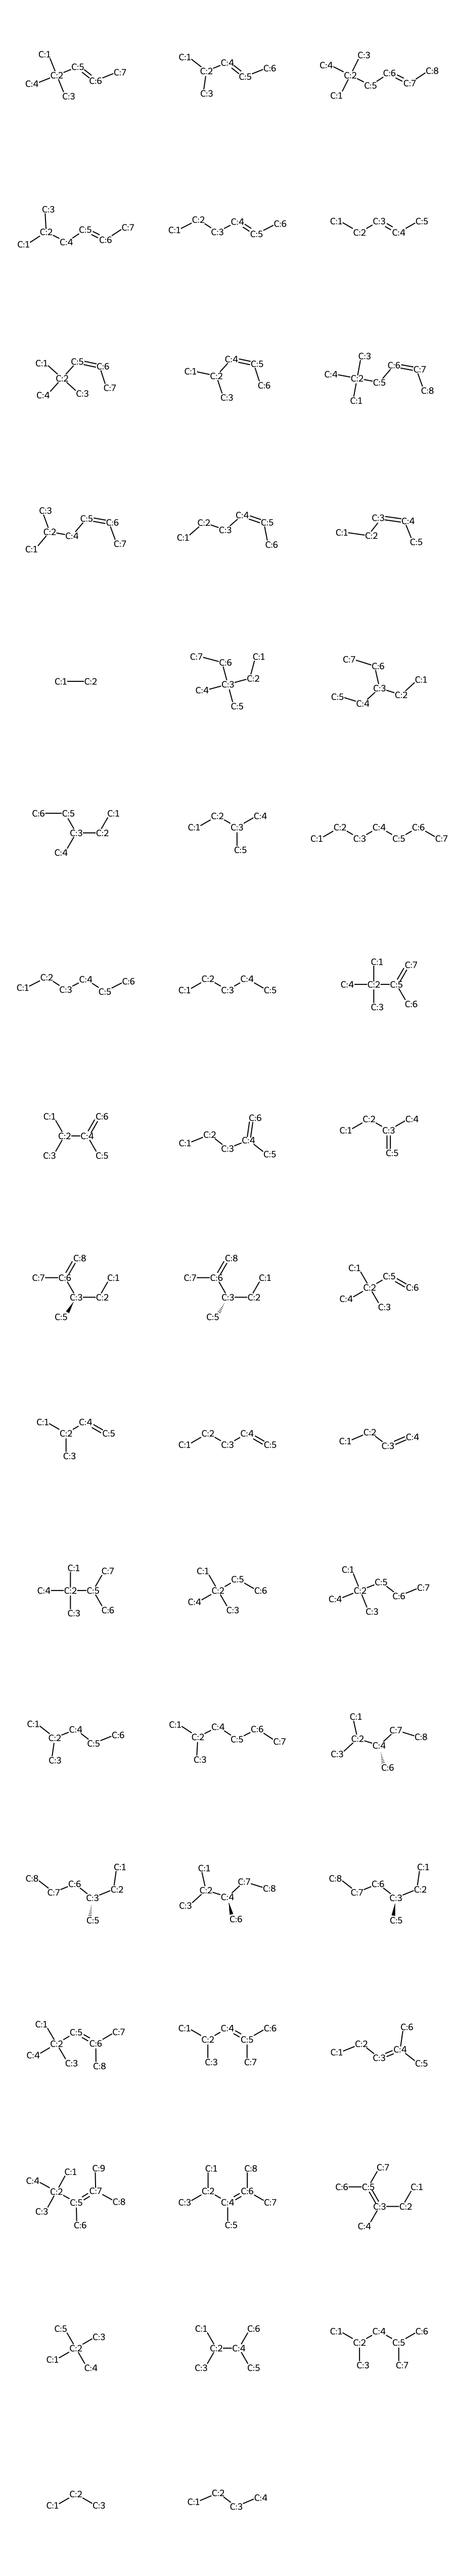

In [17]:
from rdkit import Chem
from rdkit.Chem import Draw
Draw.MolsToGridImage([Chem.MolFromSmiles(smiles) for smiles in dataset['smiles']],
                    subImgSize=(300, 300))

## Simon/descent-ff inspired fitting (something wrong here, parameters/loss not changing)

In [63]:
#optimizer = torch.optim.Adam(trainable.parameters, lr=config.learning_rate, amsgrad=True)

#if rank == 0:
#    for v in tensorboardX.writer.hparams({"optimizer": "Adam", "lr": lr}, {}):
#        writer.file_writer.add_summary(v)

for i in range(config.n_epochs):
    e_ref, e_pred, f_ref, f_pred = descent.targets.energy.predict(
        dataset, ff, topologies, "mean"
    )

    loss_energy = ((e_pred - e_ref) ** 2).sum() #/ n_entries
    loss_forces = ((f_pred - f_ref) ** 2).sum() #/ n_entries

    # k_col_torsion = trainable.force_field.potentials_by_type[
    #     "ProperTorsions"
    # ].parameter_cols.index("k")
    # prior_k_torsion = (
    #     trainable.force_field.potentials_by_type["ProperTorsions"]
    #     .parameters[:, k_col_torsion]
    #     .square()
    #     .mean()
    # )
    prior_k_torsion = torch.tensor(0.0)

    loss = loss_energy + loss_forces + prior_k_torsion
    #loss.backward()

    #torch.distributed.all_reduce(loss)
    #torch.distributed.all_reduce(loss_energy)
    #torch.distributed.all_reduce(loss_forces)
    # torch.distributed.all_reduce(prior_k_torsion)

    #for parameter in trainable.parameters:
    #    torch.distributed.all_reduce(parameter.grad)

    #trainable.freeze_grad()

    #if rank == 0:
    #    write_metrics(
    #        i, loss, loss_energy, loss_forces, prior_k_torsion, writer
    #    )
    (grad,) = torch.autograd.grad(loss, x, create_graph=True, allow_unused=True)
    x.grad = grad

    optimizer.step()
    optimizer.zero_grad()

    #trainable.clamp()

    print(f"epoch {i=}")  
    #print(f'{optimizer_loss=}')
    print(f'{loss=}')
    print(f'{loss_energy=}')
    print(f'{loss_forces=}')
    
    #if rank == 0 and i % 100 == 0:
    #if i % 100 == 0:
    #    torch.save(
    #        trainable.force_field, f"force-field-epoch-{i}.pt"
    #    )

epoch i=0
loss=tensor(406.3351, grad_fn=<AddBackward0>)
loss_energy=tensor(30.6167, grad_fn=<SumBackward0>)
loss_forces=tensor(375.7184, grad_fn=<SumBackward0>)
epoch i=1
loss=tensor(406.3351, grad_fn=<AddBackward0>)
loss_energy=tensor(30.6167, grad_fn=<SumBackward0>)
loss_forces=tensor(375.7184, grad_fn=<SumBackward0>)
epoch i=2
loss=tensor(406.3351, grad_fn=<AddBackward0>)
loss_energy=tensor(30.6167, grad_fn=<SumBackward0>)
loss_forces=tensor(375.7184, grad_fn=<SumBackward0>)
epoch i=3
loss=tensor(406.3351, grad_fn=<AddBackward0>)
loss_energy=tensor(30.6167, grad_fn=<SumBackward0>)
loss_forces=tensor(375.7184, grad_fn=<SumBackward0>)
epoch i=4
loss=tensor(406.3351, grad_fn=<AddBackward0>)
loss_energy=tensor(30.6167, grad_fn=<SumBackward0>)
loss_forces=tensor(375.7184, grad_fn=<SumBackward0>)
epoch i=5
loss=tensor(406.3351, grad_fn=<AddBackward0>)
loss_energy=tensor(30.6167, grad_fn=<SumBackward0>)
loss_forces=tensor(375.7184, grad_fn=<SumBackward0>)
epoch i=6
loss=tensor(406.3351, gr